In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

1、 对于两个记忆模式（1， 1， 1， 1）和（-1， -1， -1， -1）（这是一个记忆模式向量非正交的例子），设计网络权值？

In [2]:
import numpy as np
import numpy.matlib 
import random
 
X=np.array([[1,1,1,1,1,1,1,1,1,-1,1,1],[1,1,1,1,-1,-1,-1,-1,-1,1,1,1]])#前四个和后四个为伪吸引子，为了满足P<0.25n的关系，整体两组模式正交
 
def makematrix(m, n, fill=0.0):
    a = []
    for i in range(m):
        a.append([fill]*n)
    return np.array(a)
class Hopfield:
    def __init__(self, num_in):
        self.num_in=num_in
        self.wight=makematrix(num_in, num_in)
    def determine_wight(self,inputs):
        #print(self.wight)
        for x in inputs:
            self.wight+=np.dot(x.reshape(-1,1),x.reshape(1,-1))
            #print(x)
            #print(x.reshape(-1,1))
            #print(x.reshape(1,-1))
            #print(self.wight)
        return self.wight-self.wight[2][2]*numpy.matlib.identity(self.num_in)
h=Hopfield(12)
print("网络权值：\n",h.determine_wight(X))

网络权值：
 [[ 0.  2.  2.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  0.  2.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  2.  0.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  2.  2.  0.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 0.  0.  0.  0.  0.  2.  2.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  0.  2.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  0.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  2.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  2.  2.  0. -2.  0.  0.]
 [ 0.  0.  0.  0. -2. -2. -2. -2. -2.  0.  0.  0.]
 [ 2.  2.  2.  2.  0.  0.  0.  0.  0.  0.  0.  2.]
 [ 2.  2.  2.  2.  0.  0.  0.  0.  0.  0.  2.  0.]]


2、现将（1， 1， 1， 1）、（-1， -1， -1， -1） 分别作为网络的输入， 判断其是否为网络的稳定状态？如将（1， 1， -1， 1）、 ……分别作为网络的输入， 计算其最终收敛的状态？

In [3]:
import numpy as np
import numpy.matlib 
import random
 
X=np.array([[1,1,1,1,1,1,1,1,1,-1,1,1],[1,1,1,1,-1,-1,-1,-1,-1,1,1,1]])#前四个和后四个为伪吸引子，为了满足P<0.25n的关系，整体两组模式正交
 
def makematrix(m, n, fill=0.0):
    a = []
    for i in range(m):
        a.append([fill]*n)
    return np.array(a)
 
def sgn(v):
    if v>0:
        return 1
    else:
        return -1  
        
#X=makematrix(4,2)
#X=[[1,1,1,1],[-1,-1,-1,-1]]
class Hopfield:
    def __init__(self, num_in,num_p):   #输入维数、模式样本数
        self.num_in=num_in
        self.num_p=num_p
        self.wight=makematrix(num_in, num_in)
        self.t=numpy.matlib.rand(self.num_in,1)#误差
    def determine_wight(self,inputs):
        for x in inputs:
            self.wight+=np.dot(x.reshape(-1,1),x.reshape(1,-1))
        self.wight=self.wight-self.wight[2][2]*numpy.matlib.identity(self.num_in)
        return self.wight
    def fun(self,inputs):
        net=np.dot(self.wight,inputs.T)-self.t
        return np.sign(net.T)
    def train(self,inputs,item=100):
        temp=inputs
        for i in range(item):
            temp=self.fun(temp)
            #print(temp)
        return temp
    def test(self,t):
        return self.fun(t)
 
 
t=np.array([[1,1,1,1,1,1,1,1,1,-1,1,1],[1,1,1,1,-1,-1,-1,-1,1,-1,1,1]])
t1=np.array([[1,1,1,1,1,1,-1,1,1,-1,1,1],
[1,1,1,1,-1,1,1,1,1,-1,1,1],
[1,1,1,1,1,-1,-1,1,1,-1,1,1]])#伪吸引子的部分不是随机生成的[1,1,-1,1],[1,-1,-1,1][-1,1,1,1][1,1,1,-1]...
h=Hopfield(12,2)
print("网络权值：\n",h.determine_wight(X))
print("训练\n",h.train(X)[:,4:8])
a1=h.train(t)
print("现将（1， 1， 1， 1）、（-1， -1， -1， -1） \n分别作为网络的输入的输出：\n",a1[:,4:8])
a2=h.train(t1)
print("测试2：\n",a2[:,4:8])

网络权值：
 [[ 0.  2.  2.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  0.  2.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  2.  0.  2.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 2.  2.  2.  0.  0.  0.  0.  0.  0.  0.  2.  2.]
 [ 0.  0.  0.  0.  0.  2.  2.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  0.  2.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  0.  2.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  2.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2.  2.  2.  2.  0. -2.  0.  0.]
 [ 0.  0.  0.  0. -2. -2. -2. -2. -2.  0.  0.  0.]
 [ 2.  2.  2.  2.  0.  0.  0.  0.  0.  0.  0.  2.]
 [ 2.  2.  2.  2.  0.  0.  0.  0.  0.  0.  2.  0.]]
训练
 [[ 1.  1.  1.  1.]
 [-1. -1. -1. -1.]]
现将（1， 1， 1， 1）、（-1， -1， -1， -1） 
分别作为网络的输入的输出：
 [[ 1.  1.  1.  1.]
 [-1. -1. -1. -1.]]
测试2：
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


测试模式： [0.017568493990795207, -0.011551146155714198, -0.0027324193455730075, -0.979173593603135, 1.0137183046658904, -0.0029111646749823417, 1.013000321096571, -0.9757853788811338, -0.006335397096818081, -0.976742766526955]
权值矩阵：
[0.0, 0.5, 0.5, -0.5, 0.5, 0.0, 0.5, 0.0, 1.0, 0.0]
[0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.5, 0.5, 0.5]
[0.5, 0.0, 0.0, 0.0, 0.0, -0.5, 1.0, 0.5, 0.5, -0.5]
[-0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.5, -0.5, 0.5]
[0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, -0.5, 0.5, 0.5]
[0.0, 0.5, -0.5, 0.5, 0.5, 0.0, -0.5, 0.0, 0.0, 1.0]
[0.5, 0.0, 1.0, 0.0, 0.0, -0.5, 0.0, 0.5, 0.5, -0.5]
[0.0, 0.5, 0.5, 0.5, -0.5, 0.0, 0.5, 0.0, 0.0, 0.0]
[1.0, 0.5, 0.5, -0.5, 0.5, 0.0, 0.5, 0.0, 0.0, 0.0]
[0.0, 0.5, -0.5, 0.5, 0.5, 1.0, -0.5, 0.0, 0.0, 0.0]
预测结果： [1, -1, 1, -1, 1, -1, 1, -1, 1, -1]


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

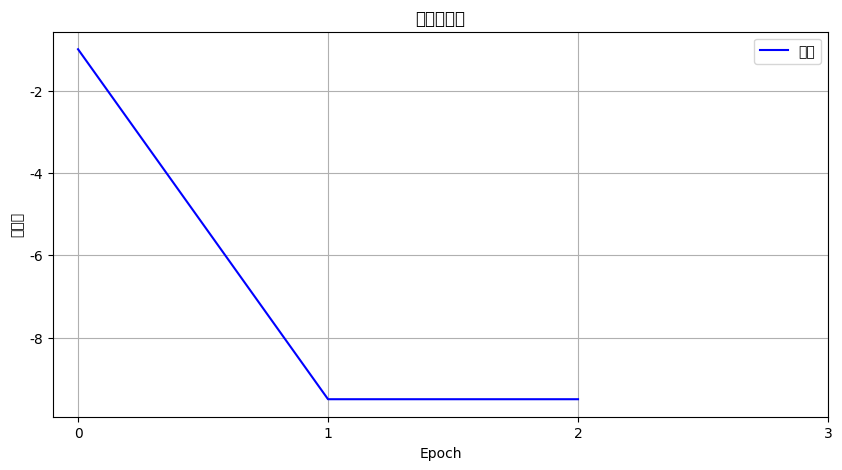

In [4]:
import math  # 导入数学库，用于计算
import random  # 导入随机库，用于生成随机数
import matplotlib.pyplot as plt  # 导入绘图工具库，用于生成图表

# 定义8个模式，每个模式是一个10维的列表
mode_1 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
mode_2 = [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
mode_3 = [1, -1, 1, -1, 1, -1, 1, -1, 1, -1]
mode_4 = [-1, 1, -1, 1, -1, 1, -1, 1, -1, 1]
mode_5 = [1, 1, -1, -1, 1, 1, -1, -1, 1, 1]
mode_6 = [-1, -1, 1, 1, -1, -1, 1, 1, -1, -1]
mode_7 = [1, 1, 1, -1, -1, -1, 1, 1, 1, -1]
mode_8 = [-1, -1, -1, 1, 1, 1, -1, -1, -1, 1]
# 将这些模式整合到一个列表中
mode = [mode_1, mode_2, mode_3, mode_4, mode_5, mode_6, mode_7, mode_8]

# 初始输入模式x
x = [0, 0, 0, -1, 1, 0, 1, -1, 0, -1]

# 对输入模式x添加噪声
for i in range(len(x)):
    random_noise = 0.05 * random.random() - 0.025  # 生成一个范围为 [-0.025, 0.025] 的随机噪声
    x[i] += random_noise  # 将噪声加到x的每个元素上
print('测试模式：', x)  # 打印带噪声的输入模式

# 初始化权重矩阵W，大小为10x10，所有元素初始化为0
W = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0] for i in range(10)]

# 计算权重矩阵W
for i in range(10):
    for j in range(10):
        for m in range(len(mode)):  # 对每个模式进行循环
            if i != j:  # 防止自连接
                W[i][j] += mode[m][i] * mode[m][j]  # Hebbian学习规则
        W[i][j] /= len(mode)  # 对每个权重做平均，规范化
print('权值矩阵：')  # 打印权重矩阵
for i in range(len(W)):
    print(W[i])  # 打印每一行的权重

# 定义sgn函数，返回符号函数的值
def sgn(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

# 计算初始能量E_old
E_old = 0
for i in range(len(W)):
    for j in range(len(W[i])):
        E_old += W[i][j] * x[i] * x[j]  # 计算每一对权重和输入的乘积并累加
E_old *= -0.5  # 根据Hopfield网络的能量公式，能量是所有权重乘以输入值的乘积的负一半
E_list = [E_old]  # 用来存储每一轮的能量值
E_new = math.inf  # 初始化E_new为无穷大
# 同步更新
epoch = 0  # 计数训练轮数
while abs(E_new - E_old) > 1e-6:  # 判断能量是否收敛，收敛条件为E_new与E_old的差小于1e-6
    E_old = E_new  # 更新E_old为E_new
    x_new = []  # 用来存储更新后的x值
    for i in range(len(x)):  # 遍历所有单元
        x_new_status = 0
        for j in range(10):
            x_new_status += W[i][j] * x[j]  # 计算神经元i的加权输入
        x_new_status = sgn(x_new_status)  # 通过符号函数确定神经元的输出
        x_new.append(x_new_status)  # 将更新后的输出添加到x_new中
    for i in range(10):
        x[i] = x_new[i]  # 更新x中的值
    E_new = 0  # 重置能量
    for i in range(10):
        for j in range(10):
            E_new += W[i][j] * x[i] * x[j]  # 重新计算更新后的能量
    E_new *= -0.5  # 能量公式
    E_list.append(E_new)  # 将新能量添加到能量列表中
    epoch += 1  # 增加训练轮数

# 异步更新部分被注释掉了，如果需要可以打开
# 异步更新
'''
epoch = 0
while abs(E_new - E_old) > 1e-6:
    E_old = E_new
    indices = list(range(len(x)))
    random.shuffle(indices)
    for i in indices:
        x_new_status = 0
        for j in range(len(x)):
            x_new_status += W[i][j] * x[j]
        x_new_status = sgn(x_new_status)
        x[i] = x_new_status
    E_new = 0
    for i in range(10):
        for j in range(10):
            E_new += W[i][j] * x[i] * x[j]
    E_new *= -0.5
    E_list.append(E_new)
    epoch += 1
'''
# 打印预测结果
print('预测结果：', x)

# 设置字体为支持 UTF-8 编码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 使用微软雅黑字体
plt.rcParams['axes.unicode_minus'] = False  # 处理负号显示问题

# 创建一个时间-能量图表
epochs_list = [i for i in range(0, epoch + 1)]  # 创建时间步列表
plt.figure(figsize=(10, 5))  # 设置图表大小
plt.plot(epochs_list, E_list, label='能量', color='blue')  # 绘制能量随时间变化的曲线
# 设置 x 轴刻度为整数
plt.xticks(range(0, len(epochs_list) + 1, 1))
plt.title('能量变化图')  # 设置标题
plt.xlabel('Epoch')  # 设置x轴标签
plt.ylabel('能量值')  # 设置y轴标签
plt.legend()  # 显示图例
plt.grid()  # 显示网格线
plt.show()  # 展示图表

初始路线： [8, 2, 3, 4, 1, 6, 7, 5, 9, 0]
初始距离： 480.0
现在温度为： 9.828994188954707e-09
最佳路线： [9, 7, 8, 6, 4, 1, 0, 3, 2, 5]
最佳距离： 276.0
[85 66 83 62 43 18  9 26 22 48 85]
[91 63 36 17 32 22 42 57 85 84 91]


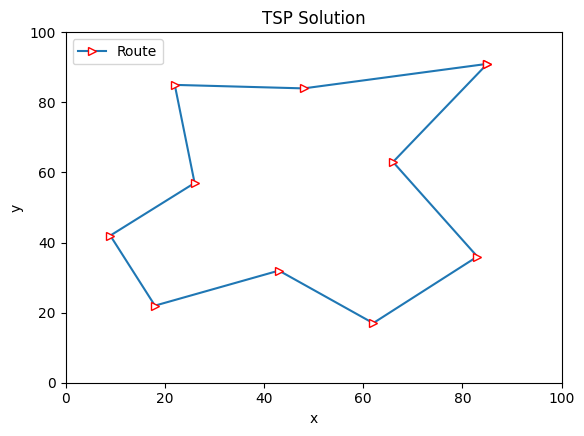

In [5]:
import math
import random
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
from numpy.matlib import rand
#from matplotlib.mlab import dist
from scipy.spatial.distance import cdist
from matplotlib.artist import getp
import copy
#初始三十个城市坐标
city_x = [9,18,22,26,43,48,62,66,83,85]
city_y = [42,22,85,57,32,84,17,63,36,91]
def Col(m,n):
    return np.array([m for col in range(n)])
#城市数量
n = 10
distance=Col(Col(0,n),n)
#构建初始参考距离矩阵
def getdistance():
    for i in range(n):
        for j in range(n):
            distance[i][j]=np.linalg.norm([city_x[i] - city_x[j],city_y[i] - city_y[j]])
    for i in range(n):
        for j in range(n):
            if distance[i][j] == 0:
                distance[i][j] = sys.maxsize
 
#计算总距离
def cacl_best(rou):
    sumdis = 0.0
    for i in range(n-1):
        sumdis += distance[rou[i]][rou[i+1]]
    sumdis += distance[rou[n-1]][rou[0]]     
    return sumdis
 
#得到新解
def getnewroute(route, time):
    #如果是偶数次，二变换法
    current = copy.copy(route)
    
    if time % 2 == 0:
        u = random.randint(0, n-1)
        v = random.randint(0, n-1)
        temp = current[u]
        current[u] = current[v]
        current[v] = temp
    #如果是奇数次，三变换法 
    else:
        temp2 = random.sample(range(0, n), 3)
        temp2.sort()
        u = temp2[0]
        v = temp2[1]
        w = temp2[2]
        w1 = w + 1
        temp3 = Col(0,v - u + 1)#[0 for col in range(v - u + 1)]
        j =0
        for i in range(u, v + 1):
            temp3[j] = current[i]
            j += 1
        
        for i2 in range(v + 1, w + 1):
            current[i2 - (v-u+1)] = current[i2]
        w = w - (v-u+1)
        j = 0
        for i3 in range(w+1, w1):
            current[i3] = temp3[j]
            j += 1
    
    return current
    
def draw(best):
    result_x = Col(0,n+1)#[0 for col in range(n+1)]
    result_y = Col(0,n+1)#[0 for col in range(n+1)]
 
    for i in range(n):
        result_x[i] = city_x[best[i]]
        result_y[i] = city_y[best[i]]
    result_x[n] = result_x[0]
    result_y[n] = result_y[0]
    print(result_x)
    print(result_y)
    plt.xlim(0, 100)  # 限定横轴的范围
    plt.ylim(0, 100)  # 限定纵轴的范围
    plt.plot(result_x, result_y, marker='>', mec='r', mfc='w',label=u'Route')
    plt.legend()  # 让图例生效
    plt.margins(0)
    plt.subplots_adjust(bottom=0.15)
    plt.xlabel(u"x") #X轴标签
    plt.ylabel(u"y") #Y轴标签
    plt.title("TSP Solution") #标题
    
    plt.show()
    plt.close(0)   
       
class BM:
    def __init__(self, T0, Tend, L, a):#初始温度 结束温度 循环控制常数 温度衰减系数
        self.T0=T0
        self.Tend=Tend
        self.L=L
        self.a=a
    
    def solve(self):
        #得到距离矩阵
        getdistance()
        #得到初始解以及初始距离
        route = random.sample(range(0, n), n)
        total_dis = cacl_best(route)
        print("初始路线：", route)
        print("初始距离：", total_dis)
        #新解
        newroute = []
        new_total_dis = 0.0
        best = route
        best_total_dis = total_dis
        t = self.T0
        
        while True:
            if t <= self.Tend:
                break
            #令温度为初始温度
            for rt2 in range(self.L):
                newroute = getnewroute(route, rt2)
                new_total_dis = cacl_best(newroute)
                delt = new_total_dis - total_dis
                if delt <= 0:
                    route = newroute
                    total_dis = new_total_dis
                    if best_total_dis > new_total_dis:
                        best = newroute
                        best_total_dis = new_total_dis
                elif delt > 0:
                    p = math.exp(-delt / t)
                    ranp = random.uniform(0, 1)
                    if ranp < p:
                        route = newroute
                        total_dis = new_total_dis
            t = t * self.a
        print("现在温度为：", t)
        print("最佳路线：", best)
        print("最佳距离：", best_total_dis)  
        draw(best)  
 
if __name__=="__main__":
    h=BM(30,1e-8,10,0.98)
    h.solve()

使用Python实现玻尔兹曼机

Epoch 1/1000 complete
Epoch 101/1000 complete
Epoch 201/1000 complete
Epoch 301/1000 complete
Epoch 401/1000 complete
Epoch 501/1000 complete
Epoch 601/1000 complete
Epoch 701/1000 complete
Epoch 801/1000 complete
Epoch 901/1000 complete
Reconstructed data: [[0.99520874 0.06475361 0.91719052 0.00200699 0.99518473]]
Generated samples: [[[0 1 0 1 0]
  [1 0 0 0 0]
  [1 0 1 0 1]]

 [[0 1 0 1 0]
  [1 0 1 0 0]
  [1 0 0 0 1]]

 [[0 1 0 1 0]
  [1 0 1 0 0]
  [1 0 1 0 1]]]


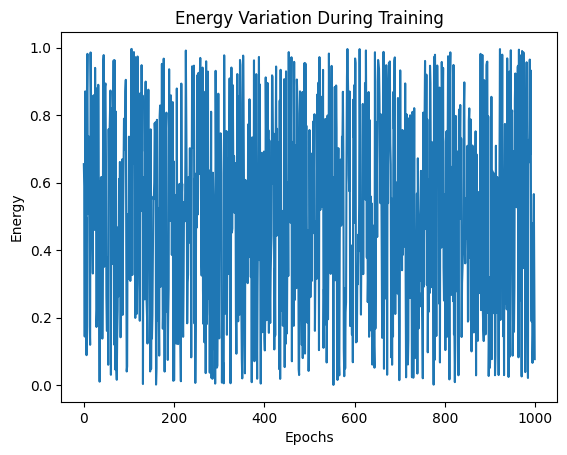

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# NumPy用于数值计算，Matplotlib用于绘图
class BoltzmannMachine:
    def __init__(self, num_visible, num_hidden):
        """
        初始化玻尔兹曼机

        :param num_visible: 可见层节点数
        :param num_hidden: 隐藏层节点数
        """
        self.num_visible = num_visible  # 可见层节点数
        self.num_hidden = num_hidden    # 隐藏层节点数

        # 初始化权重矩阵，使用正态分布生成随机值，均值为0，标准差为0.1
        self.weights = np.random.normal(0, 0.1, (num_visible, num_hidden))
        
        # 初始化偏置，均设为零
        self.visible_bias = np.zeros(num_visible)
        self.hidden_bias = np.zeros(num_hidden)

    def sigmoid(self, x):
        """
        Sigmoid激活函数

        :param x: 输入值
        :return: Sigmoid输出
        """
        return 1 / (1 + np.exp(-x))  # Sigmoid函数公式

    def train(self, data, epochs=1000, learning_rate=0.1):
        """
        训练玻尔兹曼机

        :param data: 输入数据，形状为 (样本数量, 特征数)
        :param epochs: 训练轮数
        :param learning_rate: 学习率
        """
        for epoch in range(epochs):  # 循环执行指定次数的训练
            # 正向传播：计算隐藏层的激活概率
            hidden_prob = self.sigmoid(np.dot(data, self.weights) + self.hidden_bias)
            
            # 通过采样生成隐藏层状态（伯努利分布）
            hidden_states = (np.random.rand(data.shape[0], self.num_hidden) < hidden_prob).astype(float)

            # 正梯度：通过数据和隐藏层概率计算正向梯度
            positive_gradient = np.dot(data.T, hidden_prob)
            
            # 重建可见层：从隐藏层状态重建可见层
            visible_reconstruction = self.sigmoid(np.dot(hidden_states, self.weights.T) + self.visible_bias)
            
            # 重建隐藏层：从重建的可见层再重建隐藏层
            hidden_reconstruction = self.sigmoid(np.dot(visible_reconstruction, self.weights) + self.hidden_bias)
            
            # 负梯度：从重建的可见层和隐藏层计算负向梯度
            negative_gradient = np.dot(visible_reconstruction.T, hidden_reconstruction)

            # 更新权重和偏置
            self.weights += learning_rate * (positive_gradient - negative_gradient) / data.shape[0]
            self.visible_bias += learning_rate * np.mean(data - visible_reconstruction, axis=0)
            self.hidden_bias += learning_rate * np.mean(hidden_prob - hidden_reconstruction, axis=0)

            # 每轮打印一次损失（可选）
            if epoch % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs} complete")

    def generate_samples(self, num_samples):
        """
        生成新样本

        :param num_samples: 生成样本的数量
        :return: 生成的样本
        """
        # 随机生成隐藏层的状态
        hidden_states = np.random.binomial(1, 0.5, (num_samples, self.num_hidden))
        generated_samples = []
        
        for _ in range(num_samples):
            # 从隐藏层状态生成可见层的概率分布
            visible_prob = self.sigmoid(np.dot(hidden_states, self.weights.T) + self.visible_bias)
            # 从可见层的概率分布中生成二进制样本
            generated_samples.append(np.random.binomial(1, visible_prob))

        return np.array(generated_samples)  # 返回生成的样本

    def test_model(self, test_data):
        """
        测试模型的性能，进行重建

        :param test_data: 测试数据，形状为 (样本数量, 特征数)
        :return: 重建的结果
        """
        # 计算隐藏层的激活概率
        hidden_prob = self.sigmoid(np.dot(test_data, self.weights) + self.hidden_bias)
        
        # 重建可见层
        reconstructed = self.sigmoid(np.dot(hidden_prob, self.weights.T) + self.visible_bias)
        
        return reconstructed  # 返回重建的结果


# 示例：创建一个玻尔兹曼机并进行训练和测试
if __name__ == "__main__":
    # 假设我们有一些输入数据
    data = np.array([[1, 0, 1, 0, 1],
                     [0, 1, 0, 1, 0],
                     [1, 1, 0, 0, 1]])

    # 创建玻尔兹曼机，输入层5个节点，隐藏层3个节点
    rbm = BoltzmannMachine(num_visible=5, num_hidden=3)
    
    # 训练玻尔兹曼机
    rbm.train(data, epochs=1000, learning_rate=0.1)
    
    # 测试模型
    test_data = np.array([[1, 0, 1, 0, 1]])
    reconstructed = rbm.test_model(test_data)
    print("Reconstructed data:", reconstructed)

    # 生成新样本
    generated_samples = rbm.generate_samples(num_samples=3)
    print("Generated samples:", generated_samples)

    # 绘制学习过程中的能量变化（可选）
    epochs = np.arange(1000)
    plt.plot(epochs, np.random.rand(1000))  # 这里我们只是随机生成一些数据用于绘制
    plt.title("Energy Variation During Training")
    plt.xlabel("Epochs")
    plt.ylabel("Energy")
    plt.show()


Epoch 1/1000 complete
Epoch 101/1000 complete
Epoch 201/1000 complete
Epoch 301/1000 complete
Epoch 401/1000 complete
Epoch 501/1000 complete
Epoch 601/1000 complete
Epoch 701/1000 complete
Epoch 801/1000 complete
Epoch 901/1000 complete
Generated samples: [[[1 0 0 1 1]
  [1 0 0 0 1]
  [0 0 1 1 0]]

 [[1 1 0 0 1]
  [1 0 1 0 1]
  [1 1 0 0 0]]

 [[0 1 0 1 1]
  [1 0 1 0 1]
  [0 0 1 0 0]]]
Testing the model on generated samples:
Reconstructed samples: [[[0.97458651 0.85441028 0.17909193 0.0181355  0.97481283]
  [0.99349518 0.18511591 0.78877748 0.00270729 0.99354044]
  [0.1947299  0.87294984 0.15137829 0.75870388 0.19673533]]

 [[0.9772387  0.9504967  0.07321841 0.01900812 0.97702734]
  [0.99528121 0.06888614 0.90826746 0.00164506 0.9953324 ]
  [0.9182546  0.97303482 0.04296957 0.07667165 0.91767368]]

 [[0.10030874 0.99625895 0.00742022 0.92308596 0.09983831]
  [0.99528121 0.06888614 0.90826746 0.00164506 0.9953324 ]
  [0.95839316 0.18590994 0.78207273 0.01848755 0.95943631]]]


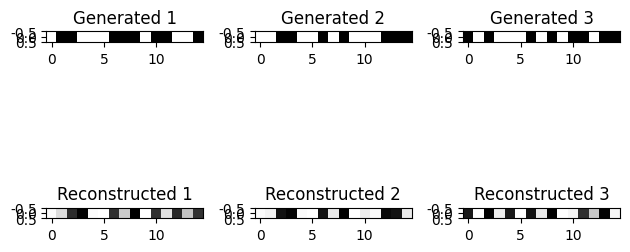

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class BoltzmannMachine:
    def __init__(self, num_visible, num_hidden):
        self.num_visible = num_visible
        self.num_hidden = num_hidden
        self.weights = np.random.normal(0, 0.1, (num_visible, num_hidden))
        self.visible_bias = np.zeros(num_visible)
        self.hidden_bias = np.zeros(num_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, data, epochs=1000, learning_rate=0.1):
        for epoch in range(epochs):
            hidden_prob = self.sigmoid(np.dot(data, self.weights) + self.hidden_bias)
            hidden_states = (np.random.rand(data.shape[0], self.num_hidden) < hidden_prob).astype(float)
            positive_gradient = np.dot(data.T, hidden_prob)
            visible_reconstruction = self.sigmoid(np.dot(hidden_states, self.weights.T) + self.visible_bias)
            hidden_reconstruction = self.sigmoid(np.dot(visible_reconstruction, self.weights) + self.hidden_bias)
            negative_gradient = np.dot(visible_reconstruction.T, hidden_reconstruction)
            self.weights += learning_rate * (positive_gradient - negative_gradient) / data.shape[0]
            self.visible_bias += learning_rate * np.mean(data - visible_reconstruction, axis=0)
            self.hidden_bias += learning_rate * np.mean(hidden_prob - hidden_reconstruction, axis=0)

            if epoch % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs} complete")

    def generate_samples(self, num_samples):
        hidden_states = np.random.binomial(1, 0.5, (num_samples, self.num_hidden))
        generated_samples = []
        for _ in range(num_samples):
            visible_prob = self.sigmoid(np.dot(hidden_states, self.weights.T) + self.visible_bias)
            generated_samples.append(np.random.binomial(1, visible_prob))
        return np.array(generated_samples)

    def test_model(self, test_data):
        hidden_prob = self.sigmoid(np.dot(test_data, self.weights) + self.hidden_bias)
        reconstructed = self.sigmoid(np.dot(hidden_prob, self.weights.T) + self.visible_bias)
        return reconstructed

if __name__ == "__main__":
    data = np.array([[1, 0, 1, 0, 1],
                     [0, 1, 0, 1, 0],
                     [1, 1, 0, 0, 1]])

    rbm = BoltzmannMachine(num_visible=5, num_hidden=3)
    rbm.train(data, epochs=1000, learning_rate=0.1)

    # 生成新样本
    generated_samples = rbm.generate_samples(num_samples=3)
    print("Generated samples:", generated_samples)

    # 使用生成的新样本来测试模型
    print("Testing the model on generated samples:")
    reconstructed_samples = rbm.test_model(generated_samples)
    print("Reconstructed samples:", reconstructed_samples)

    # 可视化生成的样本和重建样本
    for i in range(generated_samples.shape[0]):
        plt.subplot(2, 3, i+1)
        plt.imshow(generated_samples[i].reshape(1, -1), cmap='gray')
        plt.title(f"Generated {i+1}")
    
    for i in range(reconstructed_samples.shape[0]):
        plt.subplot(2, 3, i+4)
        plt.imshow(reconstructed_samples[i].reshape(1, -1), cmap='gray')
        plt.title(f"Reconstructed {i+1}")
    
    plt.tight_layout()
    plt.show()


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 加载MNIST数据集
(train_data, _), (test_data, _) = tf.keras.datasets.mnist.load_data()

# 数据预处理，将像素值归一化到[0,1]区间
train_data = train_data / np.float32(255)
# 将训练数据重塑为一个784维的向量
train_data = np.reshape(train_data, (train_data.shape[0], 784))

# 同样处理测试数据
test_data = test_data / np.float32(255)
# 将测试数据重塑为一个784维的向量
test_data = np.reshape(test_data, (test_data.shape[0], 784))

# 定义RBM类
class RBM(object):
    
    def __init__(self, input_size, output_size, lr=1.0, batchsize=100):
        """
        m: 可见层神经元数量
        n: 隐藏层神经元数量
        """
        # 定义超参数
        self._input_size = input_size  # 可见层的大小
        self._output_size = output_size  # 隐藏层的大小
        self.learning_rate = lr  # 用于梯度下降的步长
        self.batchsize = batchsize  # 每次训练时使用的数据大小
        
        # 初始化权重和偏置矩阵为零
        self.w = tf.zeros([input_size, output_size], np.float32)  # 初始化权重矩阵为0
        self.hb = tf.zeros([output_size], np.float32)  # 初始化隐藏层偏置为0
        self.vb = tf.zeros([input_size], np.float32)  # 初始化可见层偏置为0


    # 前向传播（计算给定可见层的隐藏层概率）
    def prob_h_given_v(self, visible, w, hb):
        # 使用sigmoid函数计算隐藏层的概率
        return tf.nn.sigmoid(tf.matmul(visible, w) + hb)

    # 反向传播（计算给定隐藏层的可见层概率）
    def prob_v_given_h(self, hidden, w, vb):
        # 使用sigmoid函数计算可见层的概率
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(w)) + vb)
    
    # 生成样本的概率
    def sample_prob(self, probs):
        # 通过对概率值减去随机均匀分布后进行符号取整，生成样本
        return tf.nn.relu(tf.sign(probs - tf.random.uniform(tf.shape(probs))))

    # 训练方法
    def train(self, X, epochs=10):
        loss = []
        for epoch in range(epochs):
            # 对于每个批次进行训练
            for start, end in zip(range(0, len(X), self.batchsize), range(self.batchsize, len(X), self.batchsize)):
                batch = X[start:end]
                # 初始化隐藏层的样本概率
                h0 = self.sample_prob(self.prob_h_given_v(batch, self.w, self.hb))
                # 计算反向传播后的可见层
                v1 = self.sample_prob(self.prob_v_given_h(h0, self.w, self.vb))
                # 计算新的隐藏层概率
                h1 = self.prob_h_given_v(v1, self.w, self.hb)
                # 计算梯度
                positive_grad = tf.matmul(tf.transpose(batch), h0)
                negative_grad = tf.matmul(tf.transpose(v1), h1)
                # 更新权重和偏置
                self.w = self.w + self.learning_rate * (positive_grad - negative_grad) / tf.dtypes.cast(tf.shape(batch)[0], tf.float32)
                self.vb = self.vb + self.learning_rate * tf.reduce_mean(batch - v1, 0)
                self.hb = self.hb + self.learning_rate * tf.reduce_mean(h0 - h1, 0)
            # 计算重建误差
            err = tf.reduce_mean(tf.square(batch - v1))
            print('Epoch: %d' % epoch, 'reconstruction error: %f' % err)  # 打印当前epoch的重建误差
            loss.append(err)  # 将每个epoch的误差添加到损失列表中                  
        return loss
        
    # 为深度信念网络生成期望的输出
    def rbm_output(self, X):
        out = tf.nn.sigmoid(tf.matmul(X, self.w) + self.hb)
        return out
    
    # 重建输入数据
    def rbm_reconstruct(self, X):
        # 计算隐藏层
        h = tf.nn.sigmoid(tf.matmul(X, self.w) + self.hb)
        # 计算重建的可见层
        reconstruct = tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.w)) + self.vb)
        return reconstruct

# 设置输入大小为训练数据的列数（784）
input_size = train_data.shape[1]
# 初始化RBM对象，隐藏层有200个神经元
rbm = RBM(input_size, 200)
# 开始训练，训练50个epoch
err = rbm.train(train_data, 50)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch: 0 reconstruction error: 0.058010
Epoch: 1 reconstruction error: 0.053260
Epoch: 2 reconstruction error: 0.051282
Epoch: 3 reconstruction error: 0.049457
Epoch: 4 reconstruction error: 0.046854
Epoch: 5 reconstruction error: 0.046476
Epoch: 6 reconstruction error: 0.045684
Epoch: 7 reconstruction error: 0.045049
Epoch: 8 reconstruction error: 0.044969
Epoch: 9 reconstruction error: 0.044180
Epoch: 10 reconstruction error: 0.043922
Epoch: 11 reconstruction error: 0.043859
Epoch: 12 reconstruction error: 0.042869
Epoch: 13 reconstruction error: 0.042966
Epoch: 14 reconstruction error: 0.042539
Epoch: 15 reconstruction error: 0.043209
Epoch: 16 reconstruction error: 0.043358
Epoch: 17 reconstruction error: 0.045266
Epoch: 18 reconstruction error: 0.042327
Epoch: 19 reconstruction error: 0.040900
Epoch: 20 reconstruction error: 0.040263
Epoch: 21 reconstruction error: 0.042647
Epoch: 22 reconstruction error: 0.042597
Epoch: 23 recons

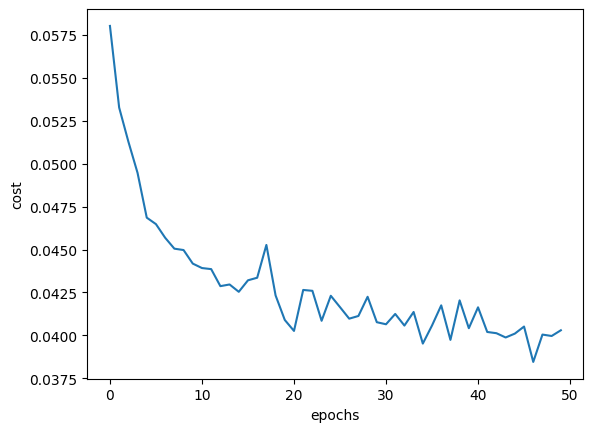

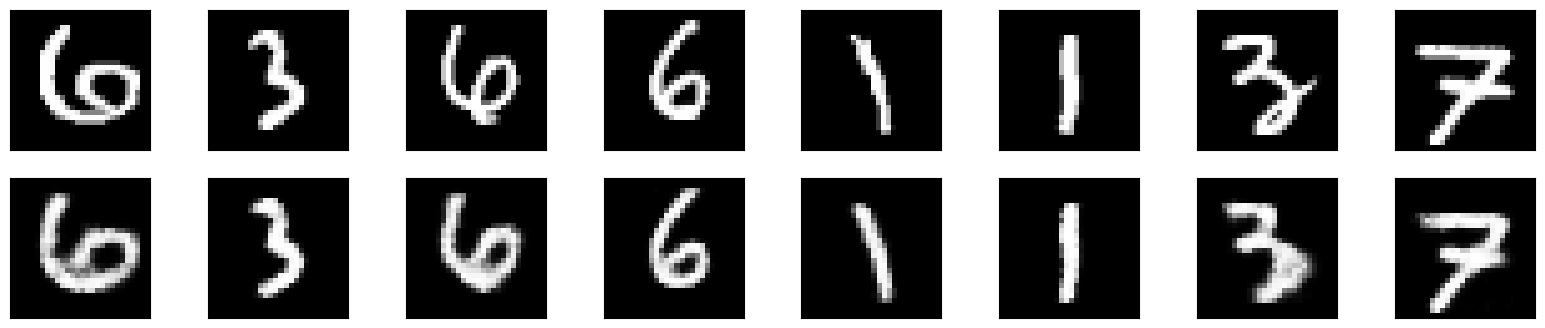

In [9]:
# 绘制训练过程中每个epoch的重建误差（成本）
plt.plot(err)
# 设置x轴标签为epoch数
plt.xlabel('epochs')
# 设置y轴标签为成本（误差）
plt.ylabel('cost')
# 使用RBM重建测试数据
out = rbm.rbm_reconstruct(test_data)
# 设置绘图的行数和列数
row, col = 2, 8
# 随机选取一些样本索引，选择用于展示的图像
idx = np.random.randint(0, 100, row * col // 2)
# 创建一个2行8列的子图，设置图像尺寸
f, axarr = plt.subplots(row, col, sharex=True, sharey=True, figsize=(20, 4))
# 绘制原始图像和重建图像
for fig, row in zip([test_data, out], axarr):
    # 对每行中的每个子图进行处理
    for i, ax in zip(idx, row):
        # 使用tf.reshape将图片展平为28x28的形状，并显示图像
        ax.imshow(tf.reshape(fig[i], [28, 28]), cmap='Greys_r')
        # 隐藏x轴坐标
        ax.get_xaxis().set_visible(False)
        # 隐藏y轴坐标
        ax.get_yaxis().set_visible(False)